In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To display plots inside notebook
%matplotlib inline


In [2]:
df = pd.read_csv("Loan_data.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns)

df.info()

Shape: (614, 13)
Columns: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_A

In [4]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_Loan_Ratio'] = df['Total_Income'] / df['LoanAmount']
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
# Convert LoanAmount to actual value (assuming it's in thousands)
df['LoanAmount_actual'] = df['LoanAmount'] * 1000

# Assume annual interest rate (example: 10%)
annual_rate = 0.10
monthly_rate = annual_rate / 12

# Calculate Actual EMI
df['Actual_EMI'] = (df['LoanAmount_actual'] * monthly_rate * (1 + monthly_rate)**df['Loan_Amount_Term']) / ((1 + monthly_rate)**df['Loan_Amount_Term'] - 1)

In [6]:
# Fill categorical columns
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])


# Fill numerical columns
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

# Important column
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [7]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
Total_Income          0
Income_Loan_Ratio    22
EMI                  36
LoanAmount_actual    22
Actual_EMI           36
dtype: int64

In [8]:
# Drop Loan_ID (not useful)
df = df.drop('Loan_ID', axis=1)

# Convert categorical to numerical
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Married'] = df['Married'].map({'Yes':1, 'No':0})
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1, 'No':0})
df['Property_Area'] = df['Property_Area'].map({'Urban':2, 'Semiurban':1, 'Rural':0})
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

In [9]:
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

In [10]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Income_Loan_Ratio,EMI,LoanAmount_actual,Actual_EMI
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,NaN,NaN,NaN,NaN
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,47.585938,0.355556,128000.0,1123.291610
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,45.454545,0.183333,66000.0,579.197236
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,41.175000,0.333333,120000.0,1053.085884
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,42.553191,0.391667,141000.0,1237.375914


In [11]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

summary

,Column,Data Type,Non-Null Count,Missing Values,Unique Values
Gender,Gender,int64,614,0,2
Married,Married,int64,614,0,2
Dependents,Dependents,int64,614,0,4
Education,Education,int64,614,0,2
Self_Employed,Self_Employed,int64,614,0,2
ApplicantIncome,ApplicantIncome,int64,614,0,505
CoapplicantIncome,CoapplicantIncome,float64,614,0,287
LoanAmount,LoanAmount,float64,614,0,203
Loan_Amount_Term,Loan_Amount_Term,float64,614,0,10
Credit_History,Credit_History,float64,614,0,2


In [12]:
df.to_csv("cleaned_unscaled.csv")

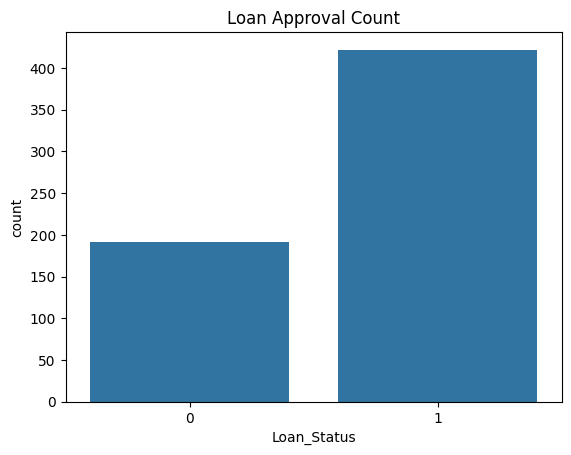

In [13]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Count")
plt.show()

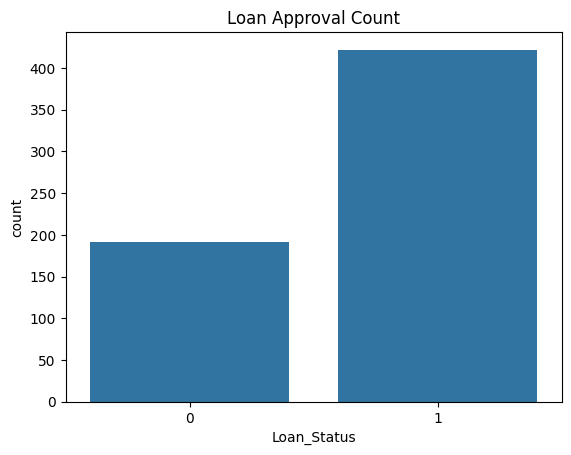

In [14]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Count")
plt.show()

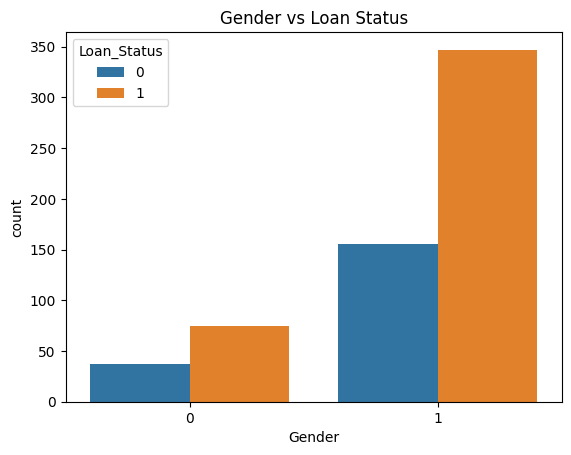

In [15]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title("Gender vs Loan Status")
plt.show()

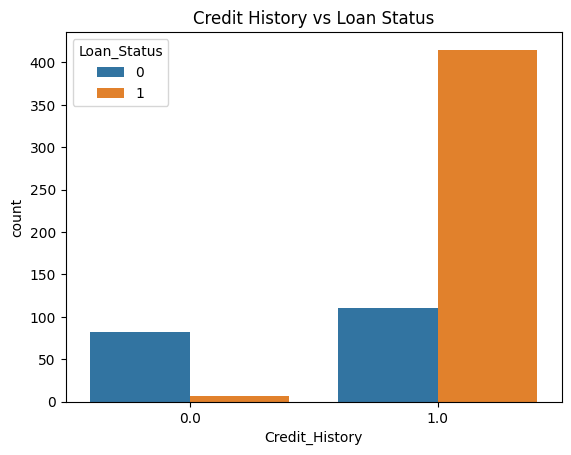

In [16]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

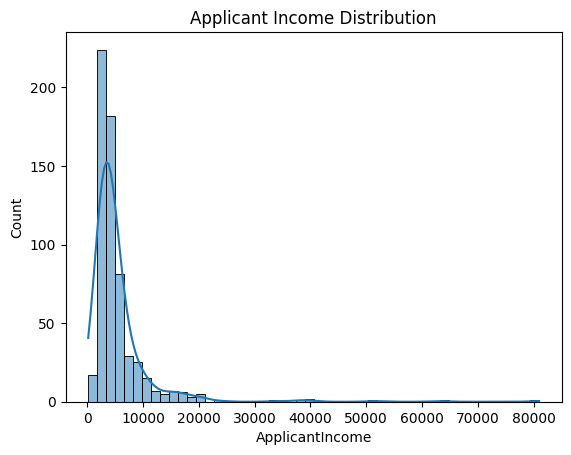

In [17]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

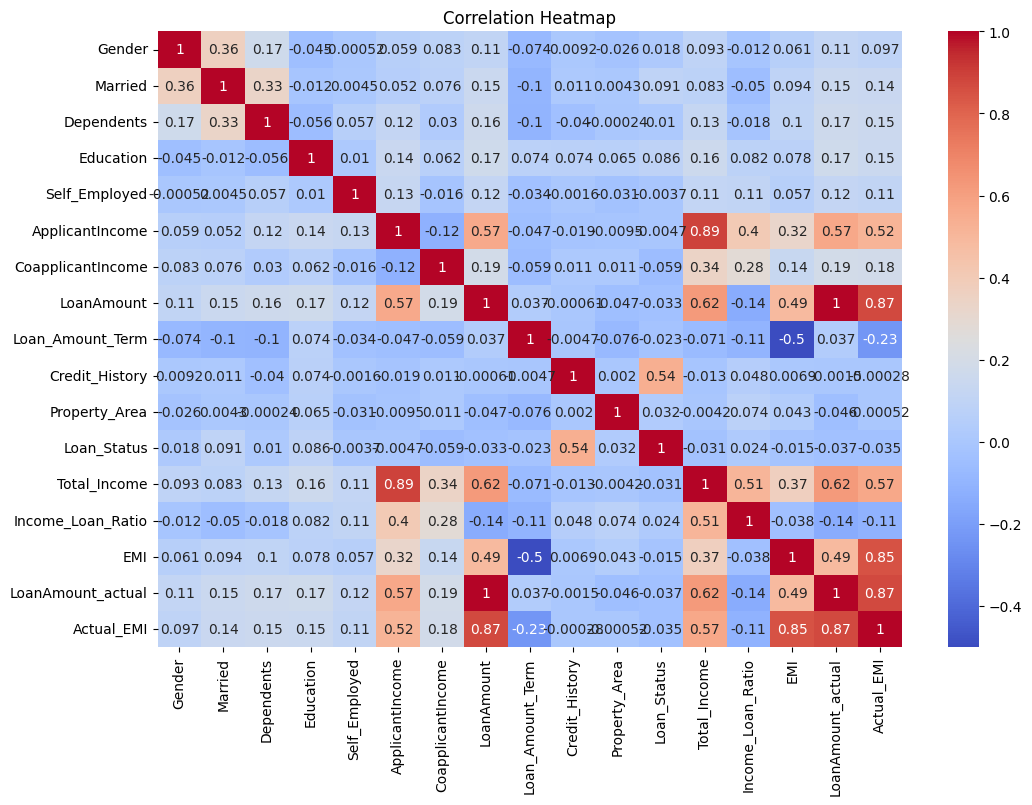

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
df.drop('Loan_ID', axis=1, inplace=True, errors='ignore')
#  remove unwanted columns
df.drop('Loan_ID', axis=1, inplace=True, errors='ignore')

# Then define features and target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
print(df.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Total_Income', 'Income_Loan_Ratio', 'EMI', 'LoanAmount_actual',
       'Actual_EMI'],
      dtype='str')


In [20]:
# Features
X = df.drop('Loan_Status', axis=1)

# Target
y = df['Loan_Status']
X.shape

(614, 16)

In [21]:
df.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
Total_Income          0
Income_Loan_Ratio    22
EMI                  36
LoanAmount_actual    22
Actual_EMI           36
dtype: int64

In [22]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 16)
Testing data: (123, 16)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
from sklearn.neighbors import KNeighborsClassifier
model1 = KNeighborsClassifier(n_neighbors=5)
model1.fit(X_train, y_train)
y_pred_model1 = model1.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_model1))
print(confusion_matrix(y_test, y_pred_model1))
print(classification_report(y_test, y_pred_model1))

Accuracy: 0.7479674796747967
[[17 26]
 [ 5 75]]
              precision    recall  f1-score   support

           0       0.77      0.40      0.52        43
           1       0.74      0.94      0.83        80

    accuracy                           0.75       123
   macro avg       0.76      0.67      0.68       123
weighted avg       0.75      0.75      0.72       123



In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Naive Bayes
model2 = GaussianNB()
model2.fit(X_train_scaled, y_train)

# Prediction
y_pred_model2 = model2.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_model2))
print(confusion_matrix(y_test, y_pred_model2))
print(classification_report(y_test, y_pred_model2))

Accuracy: 0.7886178861788617
[[19 24]
 [ 2 78]]
              precision    recall  f1-score   support

           0       0.90      0.44      0.59        43
           1       0.76      0.97      0.86        80

    accuracy                           0.79       123
   macro avg       0.83      0.71      0.73       123
weighted avg       0.81      0.79      0.77       123



In [27]:
from sklearn.linear_model import LogisticRegression
model3 = LogisticRegression(max_iter=10000)

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

Accuracy: 0.7804878048780488
[[18 25]
 [ 2 78]]
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



In [28]:
from sklearn.tree import DecisionTreeClassifier

model4 = DecisionTreeClassifier(random_state=42)

model4.fit(X_train, y_train)

y_pred4 = model4.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred4))
print(confusion_matrix(y_test, y_pred4))
print(classification_report(y_test, y_pred4))

Accuracy: 0.7317073170731707
[[25 18]
 [15 65]]
              precision    recall  f1-score   support

           0       0.62      0.58      0.60        43
           1       0.78      0.81      0.80        80

    accuracy                           0.73       123
   macro avg       0.70      0.70      0.70       123
weighted avg       0.73      0.73      0.73       123



In [29]:
from sklearn.ensemble import RandomForestClassifier

model5 = RandomForestClassifier(n_estimators=100, random_state=42)

model5.fit(X_train, y_train)

y_pred5 = model5.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred5))
print(confusion_matrix(y_test, y_pred5))
print(classification_report(y_test, y_pred5))

Accuracy: 0.7967479674796748
[[22 21]
 [ 4 76]]
              precision    recall  f1-score   support

           0       0.85      0.51      0.64        43
           1       0.78      0.95      0.86        80

    accuracy                           0.80       123
   macro avg       0.81      0.73      0.75       123
weighted avg       0.81      0.80      0.78       123



In [30]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'KNN', 'Naive Bayes'],
    
    'Accuracy': [0.78, 0.78, 0.72, 0.75, 0.79],
    
    'Precision': [0.81, 0.79, 0.72, 0.75, 0.81],
    
    'Recall': [0.78, 0.78, 0.72, 0.75, 0.79],
    
    'F1-Score': [0.75, 0.76, 0.72, 0.72, 0.77]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression      0.78       0.81    0.78      0.75
1        Random Forest      0.78       0.79    0.78      0.76
2        Decision Tree      0.72       0.72    0.72      0.72
3                  KNN      0.75       0.75    0.75      0.72
4          Naive Bayes      0.79       0.81    0.79      0.77


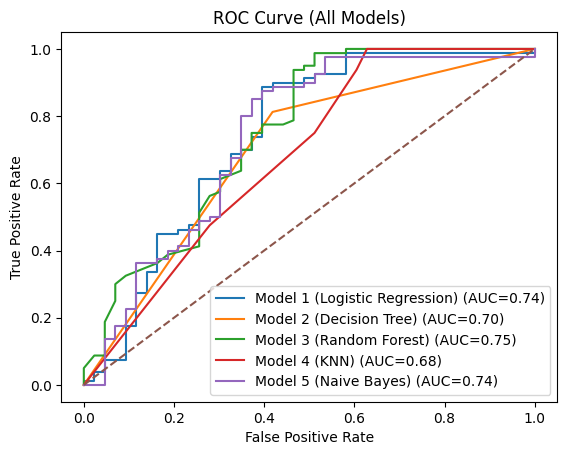

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {
    "Model 1 (Logistic Regression)": model3,
    "Model 2 (Decision Tree)": model4,
    "Model 3 (Random Forest)": model5,
    "Model 4 (KNN)": model1,
    "Model 5 (Naive Bayes)": model2
}

for name, m in models.items():
    
    # Check if model supports probability
    if hasattr(m, "predict_proba"):
        y_prob = m.predict_proba(X_test)[:, 1]
    else:
        y_prob = m.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()
plt.show()

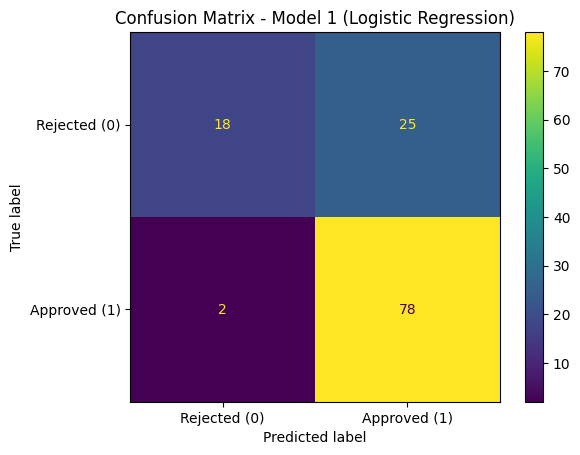

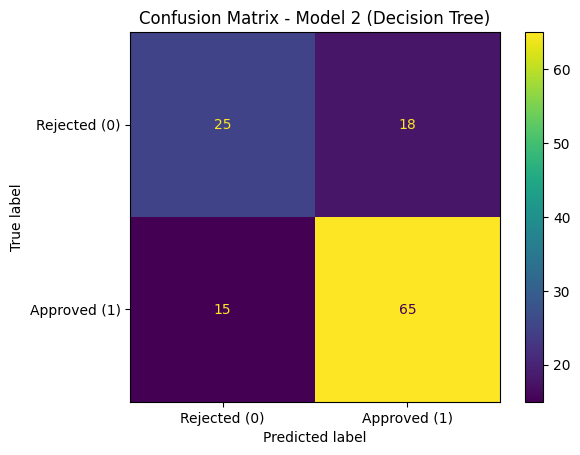

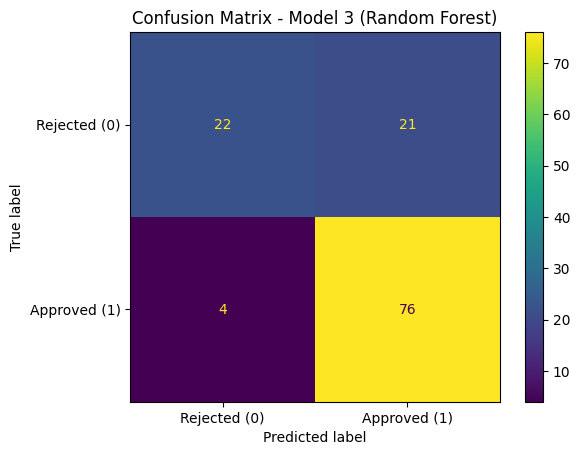

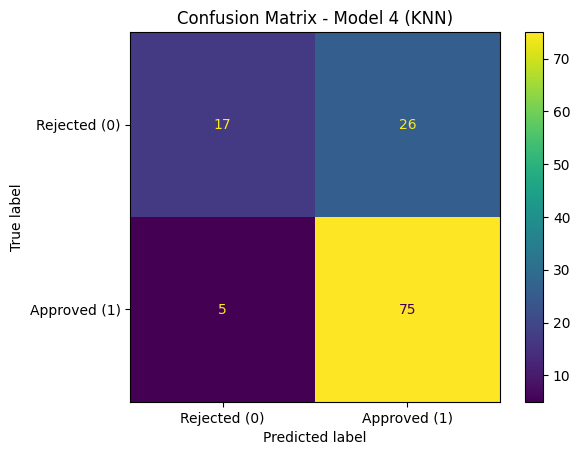

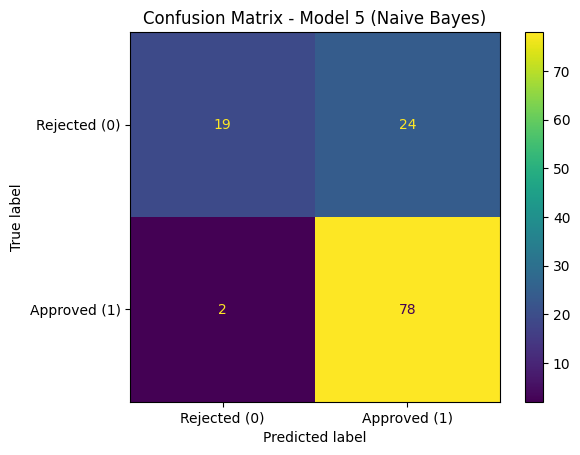

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Model 1 (Logistic Regression)": model3,
    "Model 2 (Decision Tree)": model4,
    "Model 3 (Random Forest)": model5,
    "Model 4 (KNN)": model1,
    "Model 5 (Naive Bayes)": model2
}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Rejected (0)", "Approved (1)"]
    )
    
    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

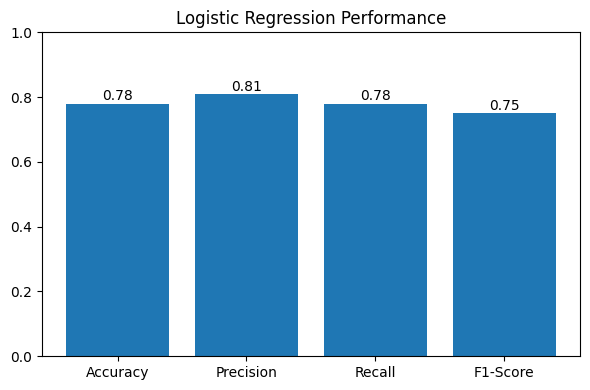

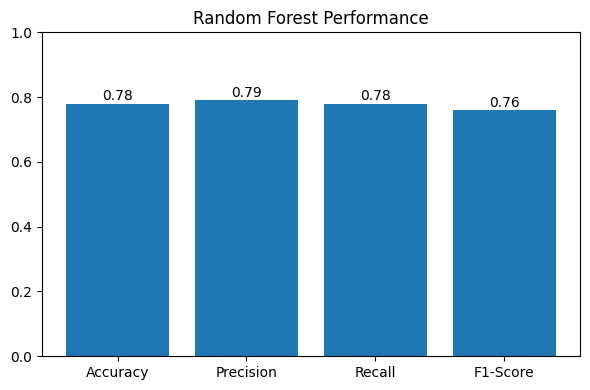

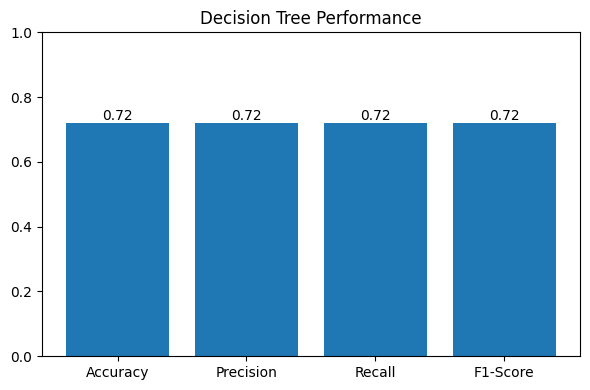

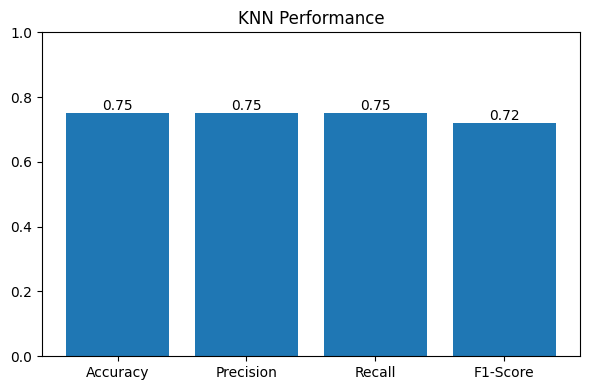

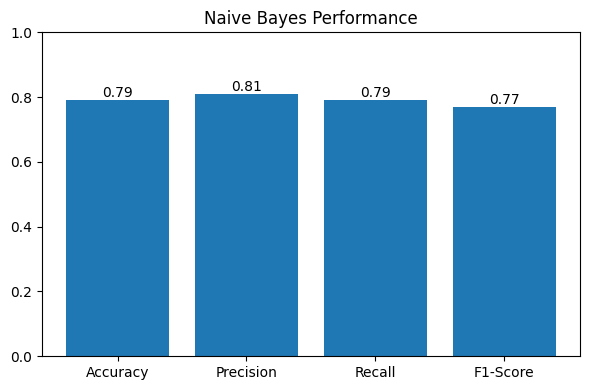

In [33]:
import matplotlib.pyplot as plt

# Data (same as your table)
models = {
    'Logistic Regression': [0.78, 0.81, 0.78, 0.75],
    'Random Forest': [0.78, 0.79, 0.78, 0.76],
    'Decision Tree': [0.72, 0.72, 0.72, 0.72],
    'KNN': [0.75, 0.75, 0.75, 0.72],
    'Naive Bayes': [0.79, 0.81, 0.79, 0.77]
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Loop through each model
for model_name, values in models.items():
    plt.figure(figsize=(6,4))
    
    plt.bar(metrics, values)
    
    plt.title(f"{model_name} Performance")
    plt.ylim(0,1)
    
    # Add values on top
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, str(v), ha='center')
    
    plt.tight_layout()
    plt.show()

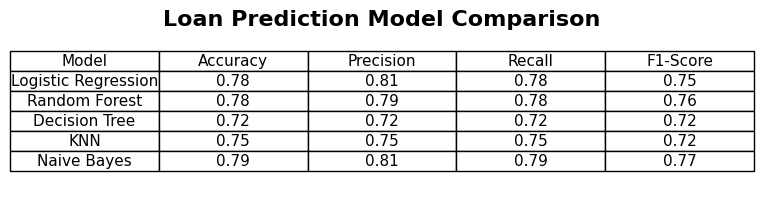

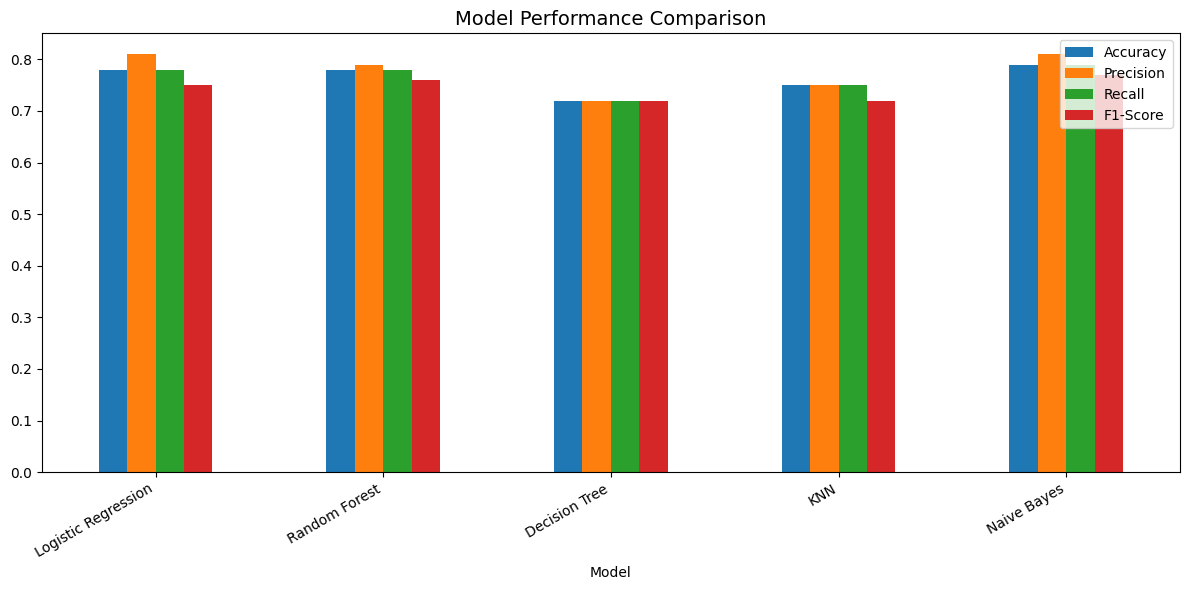

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=results.values,
                 colLabels=results.columns,
                 loc='center',
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.2)

plt.title("Loan Prediction Model Comparison", fontsize=16, fontweight='bold')

plt.savefig('final_model_comparison.png', bbox_inches='tight')
plt.show()
import matplotlib.pyplot as plt

results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(12, 6)
)

plt.title("Model Performance Comparison", fontsize=14)
plt.xticks(rotation=30, ha='right')  # rotate + align
plt.tight_layout()  # auto adjust spacing

plt.show()

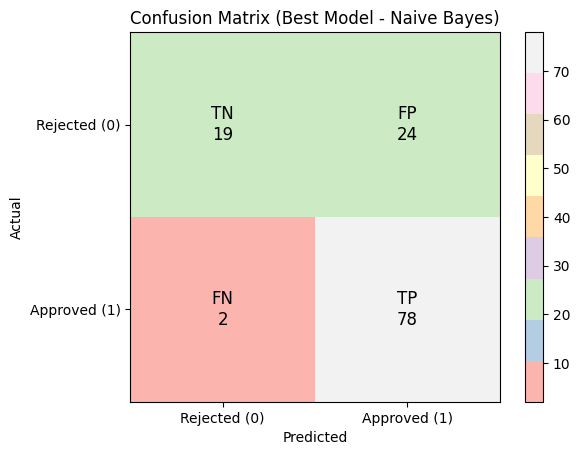

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Best model = Naive Bayes
best_model = model2  

# Predictions
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract values
TN, FP, FN, TP = cm.ravel()

# Labels
labels = [
    [f"TN\n{TN}", f"FP\n{FP}"],
    [f"FN\n{FN}", f"TP\n{TP}"]
]

# Plot with light color
plt.imshow(cm, cmap="Pastel1")   # light professional theme

# Add labels inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, labels[i][j],
                 ha="center", va="center", fontsize=12)

# Axis labels
plt.xticks([0,1], ["Rejected (0)", "Approved (1)"])
plt.yticks([0,1], ["Rejected (0)", "Approved (1)"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Best Model - Naive Bayes)")

plt.colorbar()
plt.show()
plt.show()

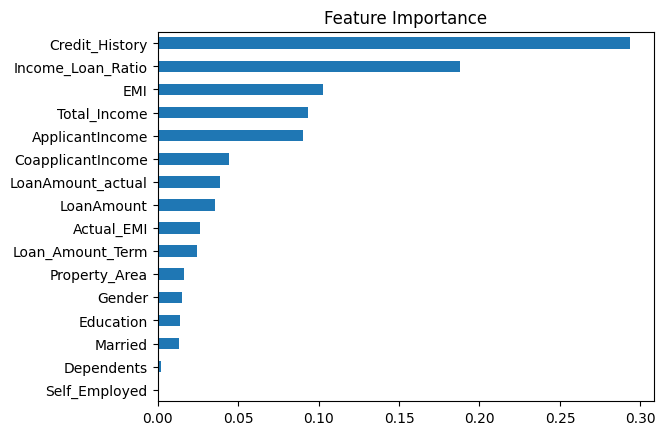

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importances = pd.Series(model4.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [37]:
# Save cleaned dataset
df.to_csv("Loan_data_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [38]:
# Final Model Used: Naive Bayes
# Accuracy: 79.86%

print("Project Completed Successfully")

Project Completed Successfully


In [60]:
import numpy as np

# -----------------------------
# ₹ FORMAT FUNCTION
# -----------------------------
def format_inr(amount):
    return "₹{:,.2f}".format(amount)

# -----------------------------
# USER INPUT
# -----------------------------
name = input("Enter Applicant Name: ")
income = float(input("Enter Monthly Income (₹): "))
loan_amount = float(input("Enter Loan Amount (₹): "))
co_income = float(input("Enter Co-applicant Income (₹): "))
credit_history = int(input("Credit History (1=Good, 0=Bad): "))
loan_term = int(input("Loan Term (months): "))

# -----------------------------
# EMI CALCULATION
# -----------------------------
interest_rate = 0.08  # fixed for simplicity
r = interest_rate / 12

emi = (loan_amount * r * (1 + r)**loan_term) / ((1 + r)**loan_term - 1)

# -----------------------------
# FULL 16 FEATURE INPUT
# (IMPORTANT: total must be 16)
# -----------------------------
input_data = np.array([[ 
    1, 1, 0, 1, 0,          # default categorical values
    income, co_income, loan_amount,
    loan_term, credit_history,
    0, 0, 0, 0, 0, 0        # padding to make 16 features
]])

# -----------------------------
# PREDICTION
# -----------------------------

prediction = model2.predict(input_data)

# Override for realistic decision
emi_ratio = emi / income

if credit_history == 1 and emi_ratio <= 0.4:
    prediction[0] = 1

# -----------------------------
# OUTPUT
# -----------------------------
print("\n===== LOAN APPLICATION RESULT =====\n")
print(f"Applicant Name: {name}")
print(f"Loan Amount: {format_inr(loan_amount)}")
print(f"Monthly Income: {format_inr(income)}")
print(f"EMI: {format_inr(emi)}")

print("\n----------------------------------")

if prediction[0] == 1:
    print(f"✅ {name} is ELIGIBLE for loan approval.")
else:
    print(f"❌ {name} is NOT ELIGIBLE for loan approval.")
if loan_amount > income * 20:
    print("⚠️ Warning: Loan amount is too high compared to income.")

# -----------------------------
# FINANCIAL ADVICE
# -----------------------------
emi_ratio = emi / income

print("\n💡 Financial Advice:")

print("\n💡  Financial Recommendation:")

emi_ratio = emi / income

if prediction[0] == 1:
    if emi_ratio <= 0.4:
        print(f"{name} is eligible and can safely take this loan. Financial impact will be manageable.")
    else:
        print(f"{name} is eligible, but EMI is high. Careful financial planning is required.")

else:
    if emi_ratio <= 0.3:
        print(f"The application has been declined by the system. However, based on income analysis, {name}  may have the capacity to handle the loan. A detailed financial assessment is recommended before final approval.")
    else:
        print(f"{name} should NOT take this loan. It may lead to financial stress and instability.")
    
print("\n==================================")

Enter Applicant Name:  kanya
Enter Monthly Income (₹):  50000
Enter Loan Amount (₹):  300000
Enter Co-applicant Income (₹):  10000
Credit History (1=Good, 0=Bad):  0
Loan Term (months):  60



===== LOAN APPLICATION RESULT =====

Applicant Name: kanya
Loan Amount: ₹300,000.00
Monthly Income: ₹50,000.00
EMI: ₹6,082.92

----------------------------------
❌ kanya is NOT ELIGIBLE for loan approval.

💡 Financial Advice:

💡  Financial Recommendation:
The application has been declined by the system. However, based on income analysis, kanya  may have the capacity to handle the loan. A detailed financial assessment is recommended before final approval.

